BS and PS displacement and origins

In [ ]:
import pygmt
import xarray as xr
import rioxarray as rxr 
import pandas as pd
import numpy as np
import os
import rasterio


# Load the grid
grid_CT = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/CT_defbathy.nc',engine='netcdf4')
grid_SR = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/SR_defbathy.nc',engine='netcdf4')

# grid = pygmt.datasets.load_earth_relief(
#     resolution="01s", region=[14.75, 15.6,36.7, 37.7], registration="gridline"
# )

grid = pygmt.datasets.load_earth_relief(
    resolution="01s", region=[14, 16.25,36.25, 38], registration="gridline"
)

#file with event description
event = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/gis/dtopo/slab_dtopo_list.csv')

#dtopo asc files
path = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/gis/dtopo/'
filenames = os.listdir(path)
for reg in ['CT','SR']:
    for f in filenames:#[:1]:
        if f.endswith(".asc"):
            fn = f.split('.')[0]
            select = event[event['EveID'] == fn]
            id = select['ID'].values[0]
            lat = select['lat'].values[0]
            lon = select['lon'].values[0]
            print(f,id,lat,lon)
            #raster processing
            xlimits = 10,20
            ylimits = 30,44
            cellsize = 0.01215
            dtopo = rasterio.open(path+'/'+f) #open ascii file
            data = dtopo.read(1) #read 
            # Create coordinates for longitude and latitude
            lon = np.linspace(xlimits[0], xlimits[1], data.shape[1])
            lat = np.linspace(ylimits[0], ylimits[1], data.shape[0])
            #flip y order as its from top to bottom
            # lon = lon[::-1]
            lat = lat[::-1]

            # Convert to xarray DataArray
            xgrid = xr.DataArray(data, coords=[lat, lon], dims=['lat', 'lon'])
            maxval = xgrid.max().values 
            minval = xgrid.min().values

            
            fig = pygmt.Figure()
            pygmt.makecpt(cmap="gray", series=[-4500, 500])
            fig.grdimage(grid=grid, frame="a", projection="M10c", cmap=True,shading=True)
            fig.grdcontour(grid=grid, levels=500,limit=[-3500, -10],annotation=False)
            fig.grdcontour(grid=grid, levels=100,limit=[-101, -99],annotation=False)
            fig.grdcontour(grid=grid, levels=50,limit=[-51, -49],annotation=False)
            pygmt.makecpt(cmap="red2green+h0", series=[-5,5,0.5], continuous=False) 
            fig.grdimage(grid=xgrid,cmap =True,transparency=35)
            fig.coast(shorelines="1p,black")

            #plot CT and SR grids area as rectangles
            if reg == 'CT':
                fig.plot(
                    data = np.array([[float(grid_CT['x'].min()),
                                    float(grid_CT['y'].min()),
                                    float(grid_CT['x'].max()),
                                    float(grid_CT['y'].max())]]),
                    style='r+s',
                    pen= "1p,blue,-",)


                fig.text(
                    x=15.4,    
                    y=37.575,
                    text="Catania",
                    font="15p,Helvetica-Bold,black",
                    justify="CM",
                    offset="0.1c",
                )
            elif reg == 'SR':
                fig.plot(
                    data = np.array([[float(grid_SR['x'].min()),
                                    float(grid_SR['y'].min()),
                                    float(grid_SR['x'].max()),
                                    float(grid_SR['y'].max())]]),
                    style='r+s',
                    pen= "1p,blue,-",)


                fig.text(
                    x=15.55,    
                    y=37.15,
                    text="Siracusa",
                    font="15p,Helvetica-Bold,black",
                    justify="CM",
                    offset="0.1c",
                )

            # fig.colorbar(position="JBC+o0/1c+w10c/0.5c+h",frame=["a","x+lDeformation","y+lm"])  
            fig.savefig(f"EQ/{id}_{reg}.png",dpi=300)
            fig.show() 

E02020N3739E02658N3366-PS-Str_PYes_Var-M902_E02417N3454_S001 17496 34.54 24.17


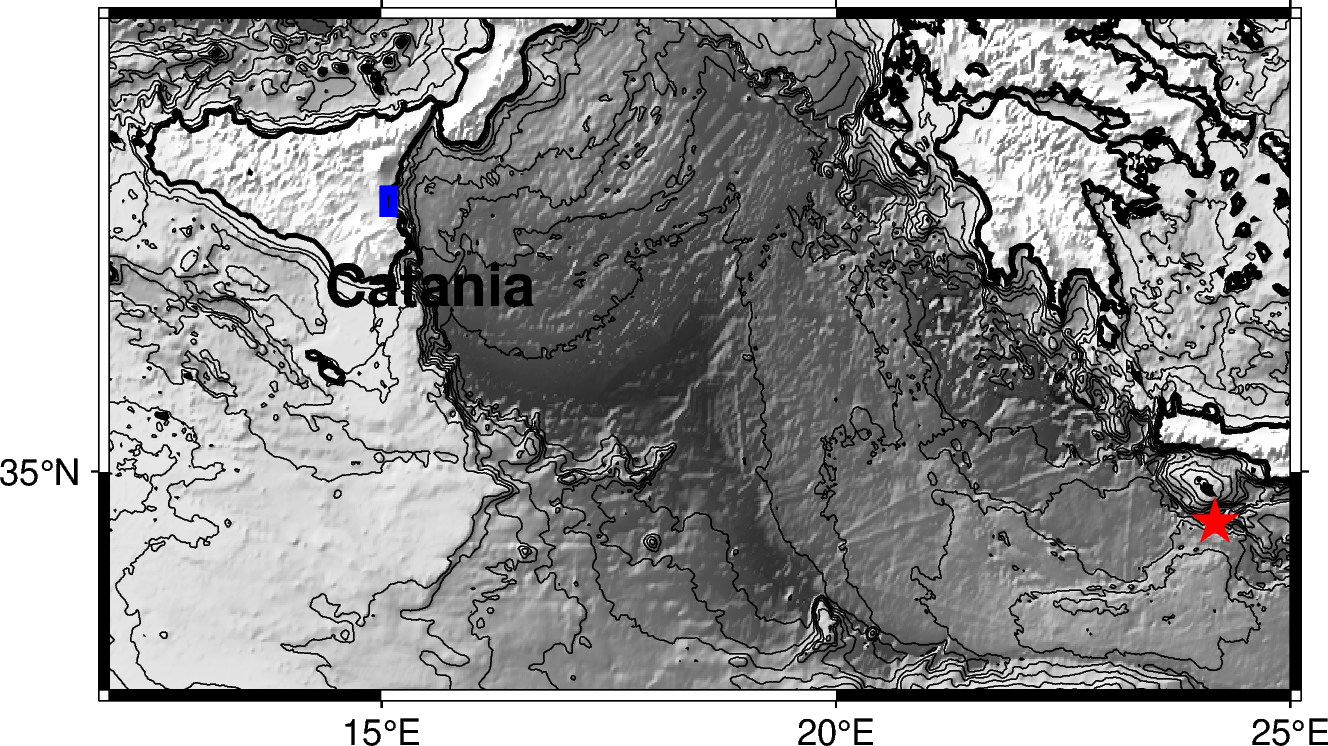

E02020N3739E02658N3366-PS-Str_PYes_Var-M895_E02351N3465_S003 7610 34.65 23.51


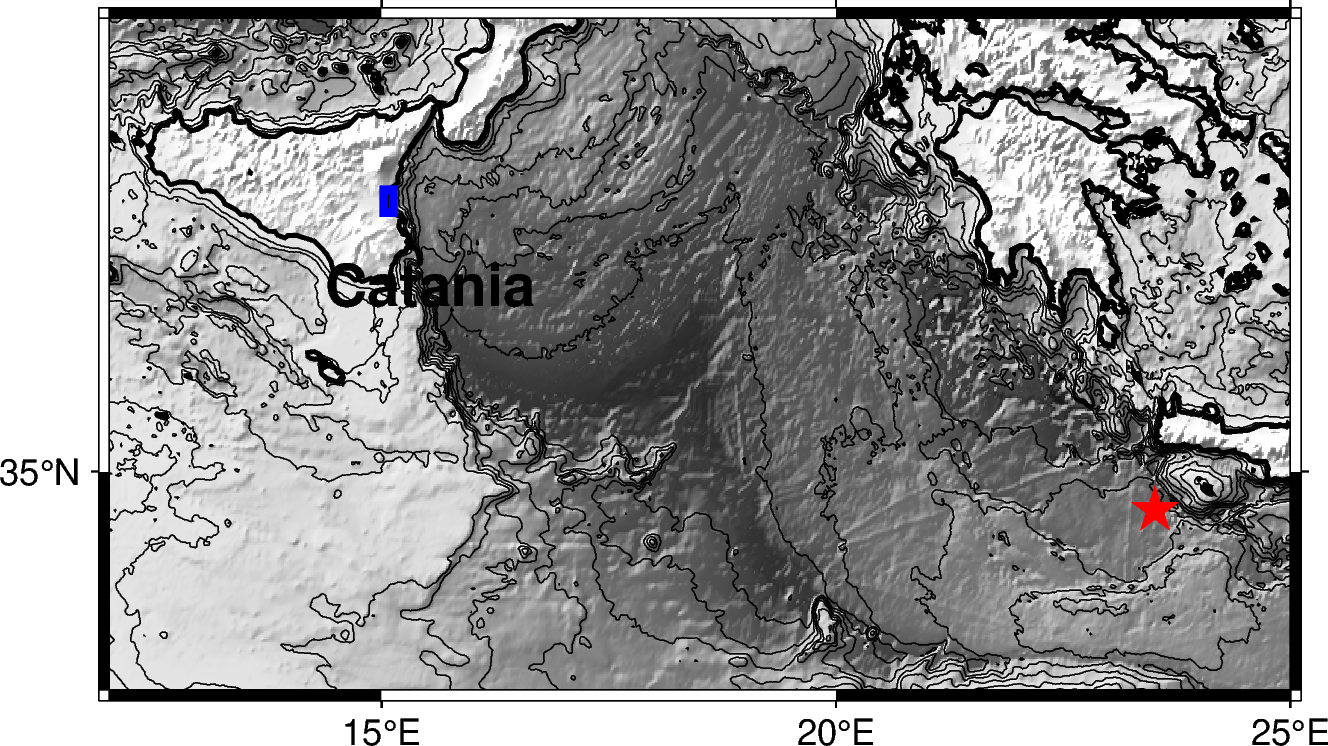

E02020N3739E02658N3366-PS-Str_PYes_Var-M902_E02417N3454_S001 17496 34.54 24.17


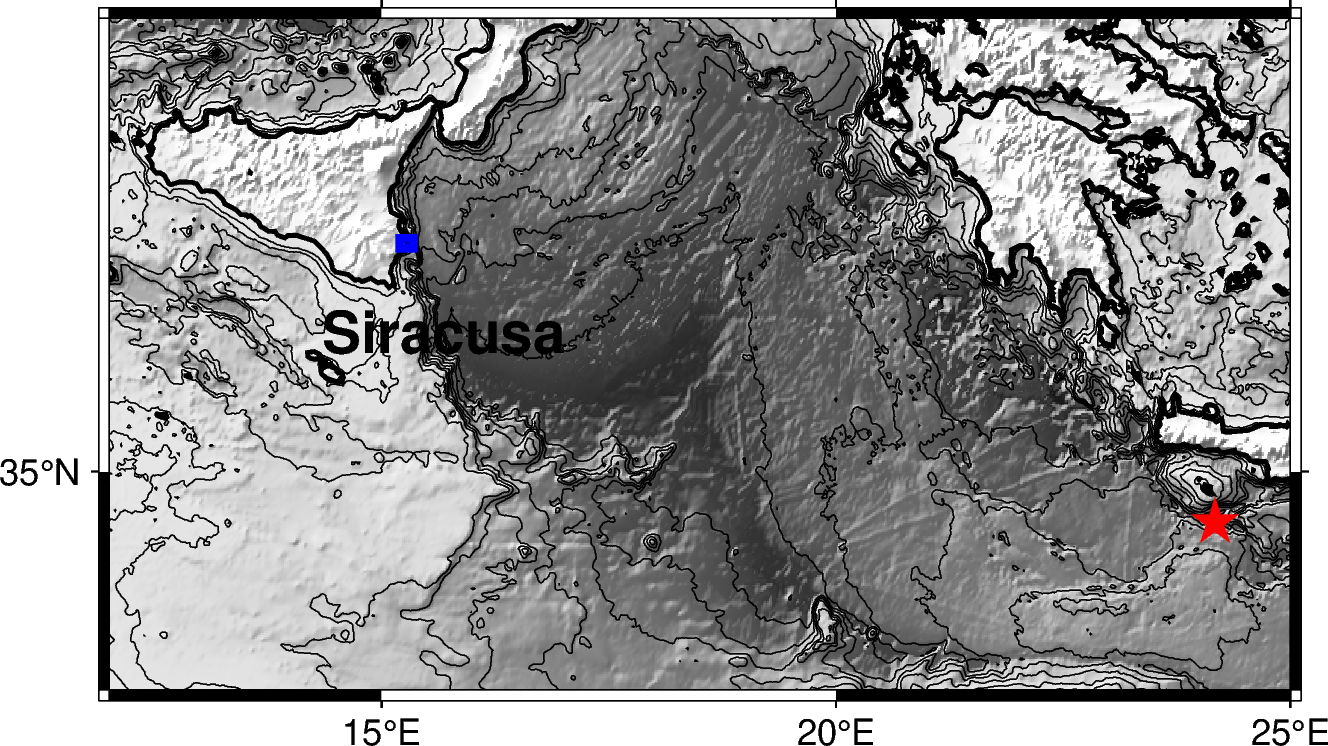

E02020N3739E02658N3366-PS-Str_PYes_Var-M895_E02351N3465_S003 7610 34.65 23.51


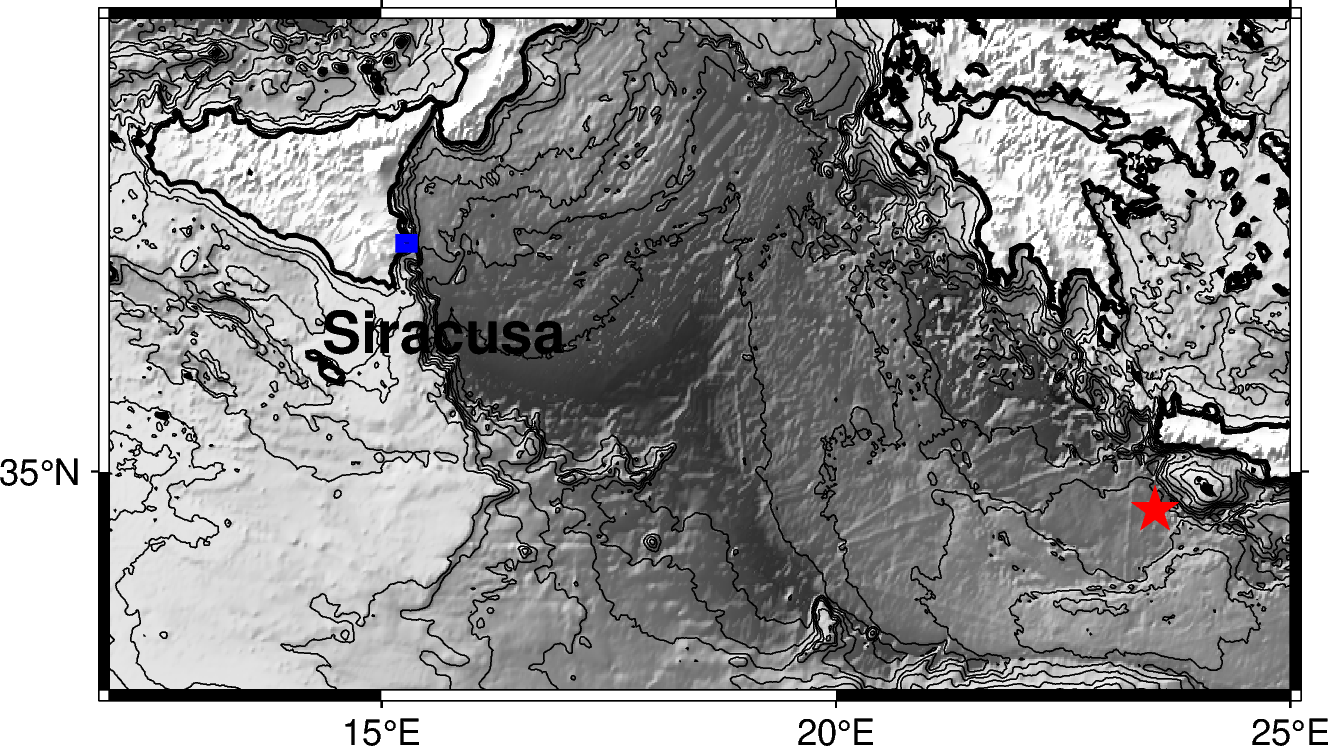

In [8]:
import pygmt
import xarray as xr
import rioxarray as rxr 
import pandas as pd
import numpy as np
import os
import rasterio


grid = pygmt.datasets.load_earth_relief(
    resolution="01m", region=[12, 25,33, 39], registration="gridline"
)

#file with event description
event = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/gis/dtopo/slab_dtopo_list.csv')
event = event[event['dep'] == 0]

# Load the grid
grid_CT = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/CT_defbathy.nc',engine='netcdf4')
grid_SR = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/SR_defbathy.nc',engine='netcdf4')

for reg in ['CT','SR']:
    for e in event['EveID']:
            select = event[event['EveID'] == e]
            id = select['ID'].values[0]
            lat = select['lat'].values[0]
            lon = select['lon'].values[0]
            print(e,id,lat,lon)
            
            fig = pygmt.Figure()
            pygmt.makecpt(cmap="gray", series=[-5000, 500])
            fig.grdimage(grid=grid, frame="a", projection="M10c", cmap=True,shading=True)
            fig.grdcontour(grid=grid, levels=500,limit=[-3500, -10],annotation=False)
            fig.grdcontour(grid=grid, levels=100,limit=[-101, -99],annotation=False)
            fig.grdcontour(grid=grid, levels=50,limit=[-51, -49],annotation=False)
            fig.coast(shorelines="1p,black")

            if reg == 'CT':
                fig.plot(
                    data = np.array([[float(grid_CT['x'].min()),
                                    float(grid_CT['y'].min()),
                                    float(grid_CT['x'].max()),
                                    float(grid_CT['y'].max())]]),
                    style='r+s',
                    pen= "2p,blue",)
                fig.text(
                    x=15.4,    
                    y=37.575-1,
                    text="Catania",
                    font="14p,Helvetica-Bold,black",
                    justify="CM",
                    offset="0.1c",
                )

            elif reg == 'SR':

                fig.plot(
                    data = np.array([[float(grid_SR['x'].min()),
                                    float(grid_SR['y'].min()),
                                    float(grid_SR['x'].max()),
                                    float(grid_SR['y'].max())]]),
                    style='r+s',
                    pen= "2p,blue",)
                fig.text(
                    x=15.55,    
                    y=37.15-1,
                    text="Siracusa",
                    font="14p,Helvetica-Bold,black",
                    justify="CM",
                    offset="0.1c",
                )


            
            #plot EQ location
            fig.plot(x=lon, y=lat,style="a0.3c", pen="1p,red", fill="red")
            fig.savefig(f"EQ/{id}_{reg}.png",dpi=300)
            fig.show() 